In [ ]:
from typing import Dict, Union, Tuple, Any, Optional
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import os
import pickle

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import wandb

In [ ]:
# Reproducing the Belief State Geometry paper Experiment on 3-State HMM
# https://arxiv.org/abs/2405.15943

### Minimal Experiment on Uniform 3-State HMM (Sierpinski Triangle)

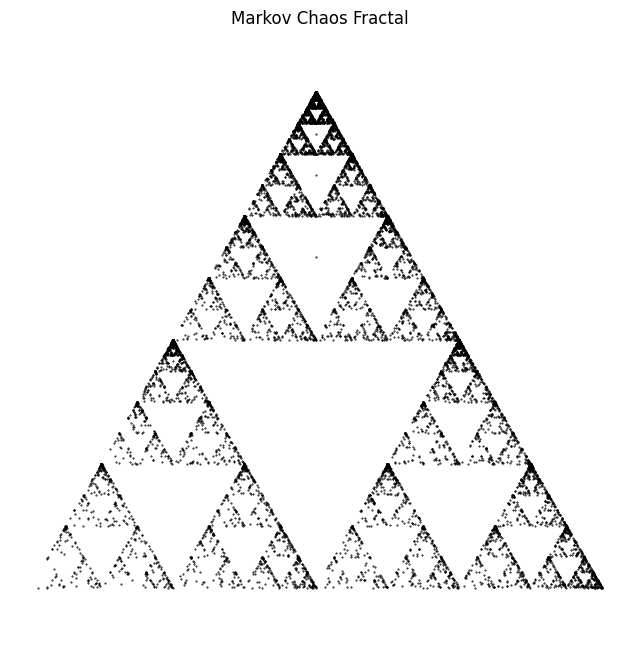

In [ ]:

# Each node is a state, each edge has {symbol: prob} for emissions
# Format: G.add_edge(from, to, emissions={"A": 0.03, "B": 0.04, "C": 0.03})
G = nx.DiGraph()
G.add_edge("S1", "S1", emissions={"A": 0.77, "B": 0.07, "C": 0.07})
G.add_edge("S1", "S2", emissions={"A": 0.03, "B": 0.04, "C": 0.03})
G.add_edge("S1", "S3", emissions={"A": 0.04, "B": 0.03, "C": 0.03})

G.add_edge("S2", "S2", emissions={"A": 0.33, "B": 0.33, "C": 0.33})
G.add_edge("S2", "S1", emissions={"A": 0.4, "B": 0.1, "C": 0.16}) # attemp to skew triangle
G.add_edge("S2", "S3", emissions={"A": 0.03, "B": 0.03, "C": 0.04})

G.add_edge("S3", "S3", emissions={"A": 0.07, "B": 0.07, "C": 0.33})
G.add_edge("S3", "S1", emissions={"A": 0.04, "B": 0.03, "C": 0.03})
G.add_edge("S3", "S2", emissions={"A": 0.03, "B": 0.03, "C": 0.04})

# 2. Define triangle vertices for A, B, C
vertices = {
    "A": np.array([0.0, 1.0]),
    "B": np.array([-np.sqrt(3)/2, -0.5]),
    "C": np.array([np.sqrt(3)/2, -0.5])
}
def simulate_fsm_chaos_uniform(G, start_state, steps):
    current_state = start_state
    point = np.array([0.0, 0.0])
    points = []

    char_traces = []
    state_traces = []

    for _ in range(steps):
        # First: compute transition probabilities (by summing emission weights)
        transition_options = []
        transition_weights = []
        for succ in G.successors(current_state):
            emissions = G[current_state][succ]['emissions']
            total_prob = sum(emissions.values())
            if total_prob > 0:
                transition_options.append(succ)
                transition_weights.append(total_prob)

        # Normalize transition probabilities
        transition_probs = [w / sum(transition_weights) for w in transition_weights]

        # Sample next state
        next_state = random.choices(transition_options, weights=transition_probs, k=1)[0]

        # Then: sample emission symbol given the transition
        emission_dict = G[current_state][next_state]['emissions']
        symbols = list(emission_dict.keys())
        symbol_weights = list(emission_dict.values())

        # Normalize emission probabilities on that edge
        emission_probs = [w / sum(symbol_weights) for w in symbol_weights]

        emitted_symbol = random.choices(symbols, weights=emission_probs, k=1)[0]

        # Chaos game move
        vertex = vertices[emitted_symbol]
        point = (point + vertex) / 2  # Is This Transferable to any HMM?
        points.append(point)

        # Update state
        current_state = next_state

        char_traces.append(emitted_symbol)
        state_traces.append(current_state)

    return np.array(points), char_traces, state_traces

# 4. Run and plot
points, char_traces, state_traces = simulate_fsm_chaos_uniform(G, start_state="S2", steps=15000)

plt.figure(figsize=(8, 8))
plt.scatter(points[:, 0], points[:, 1], s=0.2, color='black')
plt.axis('equal')
plt.axis('off')
plt.title("Markov Chaos Fractal")
plt.show()

### Generating Mess-3 HMM Model

In [ ]:
def create_hmm(states, observations, transition_matrix, initial_distribution=None):
    """
    Create a Hidden Markov Model.

    Parameters:
    -----------
    states : list of possible hidden states (vocab)
    observations : list of possible observations/emissions (vocab)
    transition_matrix : numpy.ndarray
        Matrix of Size (num_observations, num_states, num_states)
    initial_distribution : numpy.ndarray, optional
        Initial state distribution. If None, uniform distribution is used.
    """
    if initial_distribution is None:
        initial_distribution = np.ones(len(states)) / len(states)

    return {
        'states': states,
        'observations': observations,
        'transition_matrix': transition_matrix,
        'initial_distribution': initial_distribution
    }


def get_new_observation(transition_matrix: np.ndarray, currect_state: int) -> int:
    """Sampling of next Observed character. Done by fixing Source State
    and marginalizing over Destination States, then Sampling from Character vocab.
    """
    p = transition_matrix[:, currect_state, :].sum(axis=1)
    observation = np.random.choice(transition_matrix.shape[0], p=p)
    return observation


def get_new_state_and_observation(
    transition_matrix: np.ndarray, current_state_idx: int
) -> tuple[int, int]:
    """Returns tuple of Observation Char idx and next State idx.
    The idea is to sample from direct product of Emissions and States"""
    num_states = transition_matrix.shape[-1]
    transition_probs = transition_matrix[:, current_state_idx, :]
    # gives obs x num_states after flattening, hence mod by num states gives state idx
    state_observation_pair = np.random.choice(transition_probs.size, p=transition_probs.flatten())
    observation_idx = state_observation_pair // num_states
    next_state_idx = state_observation_pair % num_states
    return observation_idx, next_state_idx


def parametrize_hmm3(alpha, x):
    # 3 hidden states and 3 possible observations
    states = ["S1", "S2", "S3"]
    observations = [0, 1, 2]

    # The HMMs in this class are parameterized by alpha and x,
    # with dependent quantities β = (1 − α)/2 and y = 1 − 2x.
    beta = (1 - alpha) / 2
    y = 1 - 2*x

    # emit 0 and trasition to next state
    T_0 = np.array([
    [alpha*y, beta*x, beta*x],
    [alpha*x, beta*y, beta*x],
    [alpha*x, beta*x, beta*y]
    ])

    # emit 1 and trasition to next state
    T_1 = np.array([
        [beta*y, alpha*x, beta*x],
        [beta*x, alpha*y, beta*x],
        [beta*x, alpha*x, beta*y]
    ])

    # emit 2 and trasition to next state
    T_2 = np.array([
        [beta*y, beta*x, alpha*x],
        [beta*x, beta*y, alpha*x],
        [beta*x, beta*x, alpha*y]
    ])

    # Use the emission-specific transition matrices
    combined_transition_matrix = np.array([T_0, T_1, T_2])

    stationary_dist = get_stationary_dist(combined_transition_matrix)
    hmm_model = create_hmm(states, observations, combined_transition_matrix, stationary_dist)
    return hmm_model


def get_stationary_dist(combined_transition_matrix: np.ndarray) -> np.ndarray:
    "Tends to return 0.33x3 for MESS"
    T = combined_transition_matrix.sum(axis=0)
    T / T.sum(axis=1)
    eigenvalues, eigenvectors = np.linalg.eig(T)
    fiddler_vec = eigenvectors[:, np.isclose(eigenvalues, 1)].real
    normalized_fiddler_vec = fiddler_vec / fiddler_vec.sum()
    return normalized_fiddler_vec.squeeze()



In [ ]:
alpha = 0.65
x = 0.15

mess_1 = parametrize_hmm3(alpha, x)

In [ ]:
def sample_hmm_trajectory(hmm: dict, steps: int, current_state_idx: int=None) -> Tuple[list[int], list[int]]:
    """
    Returns Samples Trajecory of States / Trajectory of Observations
    Those are sampled from joint distribution.
    Note: we return vocab elements for both States and Observations, not indices.

    Parameters:
    -----------
    hmm : dict
        HMM model parameters
    steps : int
        Number of steps to run

    Returns:
    --------
    tuple
        (state_sequence, observations_sequence)
    """
    states = hmm['states']
    observations = hmm['observations']
    transition_matrix = hmm['transition_matrix']
    initial_distribution = hmm['initial_distribution']

    # Sample initial state
    if current_state_idx is None:
        current_state_idx = np.random.choice(len(states), p=initial_distribution)

    state_sequence = [states[current_state_idx]]
    observation_sequence = []

    for _ in range(steps):
        # Sample observation based on current state
        observation_idx, current_state_idx = get_new_state_and_observation(transition_matrix, current_state_idx)

        observation_sequence.append(observations[observation_idx])
        state_sequence.append(states[current_state_idx])

    return state_sequence, observation_sequence

In [ ]:
sample_hmm_trajectory(mess_1, 10)

(['S3', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S3'],
 [1, 2, 1, 1, 0, 1, 0, 0, 1, 0])

### Defining Optimal Belief State Update on Mess-3 HMM

In [ ]:
def get_belief_history(
    hmm_model: Dict[str, Any],
    observation_sequence: list[int], # Assuming observations are integers 0, 1, ...
    prior_dist: Optional[np.ndarray] = None
) -> np.ndarray:
    """
    Returns Trajectory of Belief State Updates.
    Should be equivalent to the paper formulation at eq. A5.

    Args:
        hmm_model: Dictionary containing HMM parameters:
            'states': List of state names/identifiers.
            'observations': List of possible observation values (e.g., [0, 1, 2]).
            'transition_matrix': np.ndarray of shape (vocab_len, num_states, num_states)
                        combined, where T[o, s, s'] = P(S_{t+1}=s', O_{t+1}=o | S_t=s).
        observation_sequence: List of observations (as integers matching indices in hmm_model['observations']).
        prior_dist: Initial belief state distribution over states (numpy array).
                    If None, uses the steady-state distribution if available in hmm_model,
                    otherwise defaults to uniform.

    Returns:
        np.array of projected 2D points representing the belief state trajectory.
        The original observation sequence.
    """
    states = hmm_model['states']
    num_states = len(states)
    transition_matrix = hmm_model['transition_matrix'] # T[o, s, s']

    # Initialize belief state (prior distribution)
    if prior_dist is not None:
        belief_state = np.array(prior_dist, dtype=float)
    elif 'steady_state' in hmm_model: # Check if steady state is precomputed
        belief_state = np.array(hmm_model['steady_state'], dtype=float)
    else:
        # Use uniform distribution if no prior or steady state provided
        belief_state = np.ones(num_states, dtype=float) / num_states

    belief_history = [belief_state] # Store the history of belief states

    # obs should be an integer index corresponding to the observation
    for obs in observation_sequence:
        # equivalent to: beta_t = belief_state @ T[obs, :, :]
        unnormalized_belief = np.einsum("s,sd->d", belief_state, transition_matrix[obs])

        # Normalize belief state
        total = np.sum(unnormalized_belief)
        belief_state = unnormalized_belief / total

        belief_history.append(belief_state)

    return  belief_history


def _print_rounded_mat(mat_or_list, up_to=3):
    print(np.round(mat_or_list, up_to))

In [ ]:
# sanity check for very skewed mess and some constant sequence

mess_skewed = parametrize_hmm3(alpha=0.99999, x=0.1)

_print_rounded_mat(mess_skewed['transition_matrix'], 3)
state_traj, char_traj = sample_hmm_trajectory(mess_skewed, 13, current_state_idx=0)

# should have extremely high intertia
print(state_traj)
print(char_traj)

[[[0.8 0.  0. ]
  [0.1 0.  0. ]
  [0.1 0.  0. ]]

 [[0.  0.1 0. ]
  [0.  0.8 0. ]
  [0.  0.1 0. ]]

 [[0.  0.  0.1]
  [0.  0.  0.1]
  [0.  0.  0.8]]]
['S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S3', 'S3', 'S3']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2]


In [ ]:
# now running belief inference starting from stationary
_print_rounded_mat(get_belief_history(mess_skewed, char_traj),3)

[[0.333 0.333 0.333]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]]


#### Plotting Belief State Geometry on 2-Simplex

In [ ]:
SIMPLEX_BOUNDARY_NODES = {
    0: np.array([0.0, 1.0]),
    1: np.array([-np.sqrt(3)/2, -0.5]),
    2: np.array([np.sqrt(3)/2, -0.5])
}

SIMPLEX_PROJ = np.array([SIMPLEX_BOUNDARY_NODES[0], SIMPLEX_BOUNDARY_NODES[1], SIMPLEX_BOUNDARY_NODES[2]])
SIMPLEX_BOUNDARY_X = np.array([SIMPLEX_BOUNDARY_NODES[0][0], SIMPLEX_BOUNDARY_NODES[1][0], SIMPLEX_BOUNDARY_NODES[2][0]])
SIMPLEX_BOUNDARY_Y = np.array([SIMPLEX_BOUNDARY_NODES[0][1], SIMPLEX_BOUNDARY_NODES[1][1], SIMPLEX_BOUNDARY_NODES[2][1]])


<ipython-input-12-c3dd5ea9336b>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(beliefs_to_simplex[:, 0], beliefs_to_simplex[:, 1], c=colors, cmap='viridis', alpha=0.7, s=0.05)


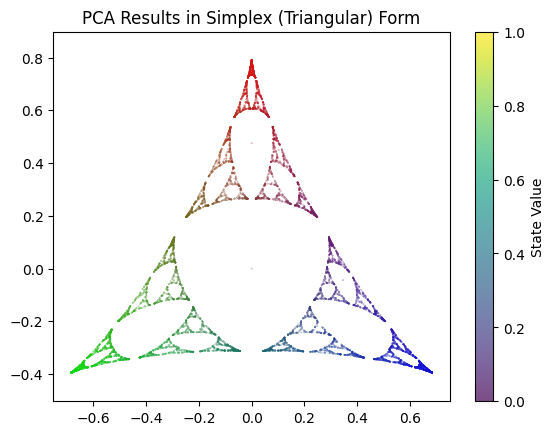

In [ ]:
mess_1 = parametrize_hmm3(alpha=0.65, x=0.15)

state_traj, char_traj = sample_hmm_trajectory(mess_1, 10000, current_state_idx=0)

long_belief_history = get_belief_history(mess_1, char_traj)

beliefs_to_simplex = np.array(long_belief_history) @ SIMPLEX_PROJ

colors = [tuple(b) for b in long_belief_history]
plt.scatter(beliefs_to_simplex[:, 0], beliefs_to_simplex[:, 1], c=colors, cmap='viridis', alpha=0.7, s=0.05)
plt.colorbar(label='State Value')
# plt.plot(SIMPLEX_BOUNDARY_X, SIMPLEX_BOUNDARY_Y,)  # Draw the simplex boundary
plt.title('PCA Results in Simplex (Triangular) Form')
plt.axis('equal')
plt.show()


#### Generating Dataset of Oberved Trajectories sampled from MESS

In [ ]:
# Train a transformer model on the character traces


# Define a simple dataset class for our character traces
class CharTraceDataset(Dataset):
    def __init__(self, char_traces, state_traces, seq_length=20):
        self.data = []
        self.state_traces = []
        self.seq_length = seq_length


        # Define vocabulary mapping
        # self.vocab = {'A': 0, 'B': 1, 'C': 2}
        self.vocab = {0: 0, 1: 1, 2: 2}
        self.state_vocab = {'S1':0, 'S2':1, 'S3':2}

        # Convert character traces to sequences
        for trace, state_trace in zip(char_traces, state_traces):
            # Convert to list if it's a string
            if isinstance(trace, str):
                trace = list(trace)

            # Convert characters to indices using vocab
            indices = [self.vocab[c] for c in trace][:seq_length]
            state_indices = [self.state_vocab[s] for s in state_trace][:seq_length]
            self.data.append(indices)
            self.state_traces.append(state_indices)


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the sequence data
        sequence = self.data[idx]
        state_seq = self.state_traces[idx]

        input_seq = torch.tensor(sequence[:-1], dtype=torch.long)
        target_seq = torch.tensor(sequence[1:], dtype=torch.long)
        state_seq = torch.tensor(state_seq[:-1], dtype=torch.long) # current state, not next state
        return input_seq, target_seq, state_seq

#### Note
1. At this point it became a bit unclear what kind of dataset composition was used to train the mode in the paper,
2. in particular if we used all unique short (length 10) trajectories (equally sampled starting from each state)
3. or first generated a handful of trajectories and run multiple epochs on them
4. or perhaps (unlikely) used long trajector(ies) that were later split into many smaller ones
5. I was conditioned on "15M tokens used for training" and Unbiased initial State representation:


Final Note, from here I mostly worked with simplest `mess-1` configuration

In [ ]:
all_char_traces = []
all_state_traces = []


num_trajectories_per_state = 1_000_000
steps = 10

# This would be better done with multiprocessing, but not sure how it behaves in collab
for start_state_idx in [0, 1, 2]:
    for _ in tqdm(range(num_trajectories_per_state)):
        state_trace, char_trace = sample_hmm_trajectory(mess_1, current_state_idx=start_state_idx, steps=steps)
        all_state_traces.append(state_trace)
        all_char_traces.append(char_trace)

print(f"Generated {len(all_char_traces)} trajectories in total")

# Create dataset and save it to avoid long re-computation
dataset = CharTraceDataset(all_char_traces, all_state_traces)


100%|██████████| 1000000/1000000 [04:33<00:00, 3655.10it/s]

Generated 3000000 trajectories in total


In [ ]:
# Note: Saving to *your* Google Drive (Collab does not Persist files, at least not free version)
from google.colab import drive
drive.mount('/content/drive')

# Use the same filename as saved above
filepath = f"/content/drive/MyDrive/chaos_game_dataset_alpha_{alpha}_x_{x}.pkl"

Mounted at /content/drive


In [ ]:
# Save the dataset
with open(filepath, 'wb') as f:
    pickle.dump({
        'char_traces': all_char_traces,
        'state_traces': all_state_traces
    }, f)

print(f"Dataset saved to {filepath}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset saved to /content/drive/MyDrive/chaos_game_dataset_alpha_0.65_x_0.15.pkl


In [ ]:
# Immediately load the dataset back from file... still useful for later re-use
import pickle
import os

# Load the dataset
with open(filepath, 'rb') as f:
    loaded_data = pickle.load(f)
    loaded_char_traces = loaded_data['char_traces']
    loaded_state_traces = loaded_data['state_traces']

print(f"Dataset loaded from {filepath}")
print(f"Number of character traces: {len(loaded_char_traces)}")
print(f"Number of state traces: {len(loaded_state_traces)}")

# Create dataset and dataloader from loaded data
dataset = CharTraceDataset(loaded_char_traces, loaded_state_traces)
dataloader = DataLoader(dataset, batch_size=800, shuffle=True)

Dataset loaded from /content/drive/MyDrive/chaos_game_dataset_alpha_0.65_x_0.15.pkl
Number of character traces: 3000000
Number of state traces: 3000000


### Training Model

Note: I've decided to avoid using Transformer Lens since I was not going to replicate the OV / KQ circtuits results and residual stream activations can be easily obtained from `pytorch` or `transformers` based model

#### Checking Linear Encoding of Optimal Belief State Geometry inside Model's Activations

In [ ]:
# Define a simple transformer model
class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size=3, d_model=64, nhead=2, num_layers=1, max_seq_length=10):
        super(SimpleTransformer, self).__init__()
        from transformers import GPT2Config, GPT2Model

        # Configure a GPT2 model with our parameters
        self.config = GPT2Config(
            vocab_size=vocab_size,
            n_embd=d_model,
            n_layer=num_layers,
            n_head=nhead,
            n_positions=max_seq_length
        )

        # Initialize the GPT2 model
        self.transformer = GPT2Model(self.config)
        self.unembed = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x shape: [seq_len, batch_size]
        output = self.transformer(x)
        output = self.unembed(output.last_hidden_state)
        return output

In [ ]:
# we will check KL divergence against optimal superposition of beliefs at some points

import torch.nn.functional as F

def ensure_tensor(p, q):
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)
    return p, q

def _normalize(p):
    return p / p.sum()

def kl_divergence(p, q):
    p, q = ensure_tensor(p, q)
    p, q = _normalize(p), _normalize(q)
    return F.kl_div(q.log(), p, reduction="sum").item()


def compute_kl_divergence_callback(output: torch.Tensor, data_batch: torch.Tensor, hmm_model: dict):
    # note: not ideal that we mix at arguments tensor and numpy array
    # Get model predictions (distributions over next character)
    with torch.no_grad():
        pred_distributions = F.softmax(output.view(-1, 3), dim=1).cpu().numpy()

    # Get optimal distributions from HMM model
    batch_trajectories = data_batch.cpu().numpy()
    optimal_distributions = []

    for trajectory in batch_trajectories:
        # Get belief history for this trajectory
        belief_history = get_belief_history(hmm_model, trajectory)
        # Get the last belief state
        last_belief = belief_history[-1]

        # Compute weighted sum of transition matrices
        weighted_transition = np.zeros((3, 3))
        for i in range(3):
            weighted_transition += last_belief[i] * hmm_model['transition_matrix'][i]

        # Get distribution over next character from weighted transition
        optimal_dist = np.sum(weighted_transition, axis=1)
        optimal_distributions.append(optimal_dist)

    optimal_distributions = np.array(optimal_distributions)

    # Compute average KL divergence
    kl_divs = []
    for pred, opt in zip(pred_distributions, optimal_distributions):
        kl_divs.append(kl_divergence(pred, opt))

    avg_kl_div = np.mean(kl_divs)
    return avg_kl_div

In [ ]:
# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note: I've tried training single layer transformer as reported in paper,
# but it refused to elicit fractal structure in its activation after training for several hours
model = SimpleTransformer(vocab_size=3, d_model=64, nhead=4, num_layers=4, max_seq_length=10).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001, weight_decay=0.00001)

In [ ]:
# test that kl divergence callback works

input_seq, target_seq, state_seq = next(iter(dataloader))

In [ ]:
model.eval()

output = model(input_seq)

compute_kl_divergence_callback(output, input_seq, mess_1)

np.float64(0.10633366525173188)

In [ ]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: culpritgene to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

1. 15M tokens on a single layer transformer did not originally gave anything resembling fractla, though 3 triangular clusters were well discernable
2. I experimented with large input datase and larger transformer size, but the results of the comparable crisp quality to the ones displayed in the paper were not obtainable
3.

In [ ]:
wandb.init(project="belief-state-geometry", name="chaos-game-transformer")

os.makedirs("experiments/checkpoints", exist_ok=True)

kl_trace = []
# Training loop
num_epochs = 25  # 5 times larger than what is mentioned in the paper!!!
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, (data, target, _) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        # Reshape for loss calculation
        loss = criterion(output.view(-1, 3), target.reshape(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Log batch metrics to wandb
        wandb.log({"batch_loss": loss.item(), "batch": batch_idx + epoch * len(dataloader)})

        # Only print batch progress every 100 batches and on 10th epochs
        if batch_idx % 1000 == 0:
            # Compute KL divergence between predicted and optimal distributions
            if batch_idx % 1000 == 0 and data.size(0) > 0:
                # Compute KL divergence and log it separately
                kl_div = compute_kl_divergence_callback(output, data, mess_1)
                kl_trace.append(kl_div)
                # Log KL divergence as a separate metric track
                wandb.log({
                    "kl_divergence": kl_div,
                    "batch": batch_idx + epoch * len(dataloader)
                })
            print(f'Epoch: {epoch+1}, Batch: {batch_idx}, Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(dataloader)


    if batch_idx % 2000 == 0:
        print(f'Progress: {batch_idx}/{len(dataloader)} batches, Average Loss: {avg_loss:.4f}')

    # Log metrics to wandb with batch granularity instead of epoch
    wandb.log({"progress_percentage": (batch_idx / len(dataloader)) * 100, "running_avg_loss": avg_loss})

    # Track total tokens processed
    tokens_processed = (epoch + 1) * len(dataloader) * dataloader.batch_size * 10

    # Save checkpoint every 1 million tokens
    if tokens_processed % 1000000 < dataloader.batch_size * 10:
        checkpoint_path = f"/content/drive/MyDrive/transformer_chaos_game_tokens_{tokens_processed}.pt"
        torch.save({
            'epoch': epoch + 1,
            'tokens_processed': tokens_processed,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, checkpoint_path)
        wandb.save(checkpoint_path)  # Also save to wandb
        print(f"Checkpoint saved at {tokens_processed} tokens")

print("Training complete!")

# Save the final model
torch.save(model.state_dict(), '/content/drive/MyDrive/transformer_chaos_game.pt')
wandb.save('transformer_chaos_game.pt')

wandb.finish()

Epoch: 1, Batch: 0, Loss: 1.2473
Epoch: 1, Batch: 1000, Loss: 1.0923
Epoch: 1, Batch: 2000, Loss: 1.0881
Epoch: 1, Batch: 3000, Loss: 1.0846
Checkpoint saved at 30000000 tokens
Epoch: 2, Batch: 0, Loss: 1.0898
Epoch: 2, Batch: 1000, Loss: 1.0877
Epoch: 2, Batch: 2000, Loss: 1.0847
Epoch: 2, Batch: 3000, Loss: 1.0861
Checkpoint saved at 60000000 tokens
Epoch: 3, Batch: 0, Loss: 1.0841
Epoch: 3, Batch: 1000, Loss: 1.0865
Epoch: 3, Batch: 2000, Loss: 1.0901
Epoch: 3, Batch: 3000, Loss: 1.0868
Checkpoint saved at 90000000 tokens
Epoch: 4, Batch: 0, Loss: 1.0843
Epoch: 4, Batch: 1000, Loss: 1.0826
Epoch: 4, Batch: 2000, Loss: 1.0822
Epoch: 4, Batch: 3000, Loss: 1.0846
Checkpoint saved at 120000000 tokens
Epoch: 5, Batch: 0, Loss: 1.0856
Epoch: 5, Batch: 1000, Loss: 1.0858
Epoch: 5, Batch: 2000, Loss: 1.0844
Epoch: 5, Batch: 3000, Loss: 1.0829
Checkpoint saved at 150000000 tokens
Epoch: 6, Batch: 0, Loss: 1.0842
Epoch: 6, Batch: 1000, Loss: 1.0857
Epoch: 6, Batch: 2000, Loss: 1.0808
Epoch: 6

batch,▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇██
batch_loss,██▆▅▆█▂▅▆▄▄▂▃▅▇▆▄▂▅▃▄▇▄▃▁▄▅▇█▃▅▇▇▆▆▇▄█▃▁
kl_divergence,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
progress_percentage,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
running_avg_loss,█▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch,93749
batch_loss,1.081
kl_divergence,0.03519
progress_percentage,99.97333
running_avg_loss,1.08244


In [ ]:
# torch.save(model.state_dict(), '/content/drive/MyDrive/transformer_chaos_game.pt')
# training_dict =  torch.load('/content/drive/MyDrive/transformer_chaos_game.pt')
model.load_state_dict(torch.load('/content/drive/MyDrive/transformer_chaos_game.pt', map_location=torch.device('cpu')))
model.eval()

SimpleTransformer(
  (transformer): GPT2Model(
    (wte): Embedding(3, 64)
    (wpe): Embedding(10, 64)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPT2Block(
        (ln_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=192, nx=64)
          (c_proj): Conv1D(nf=64, nx=64)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=256, nx=64)
          (c_proj): Conv1D(nf=64, nx=256)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (unembed): Linear(in_features=64, out_features=3, bias=True)
)

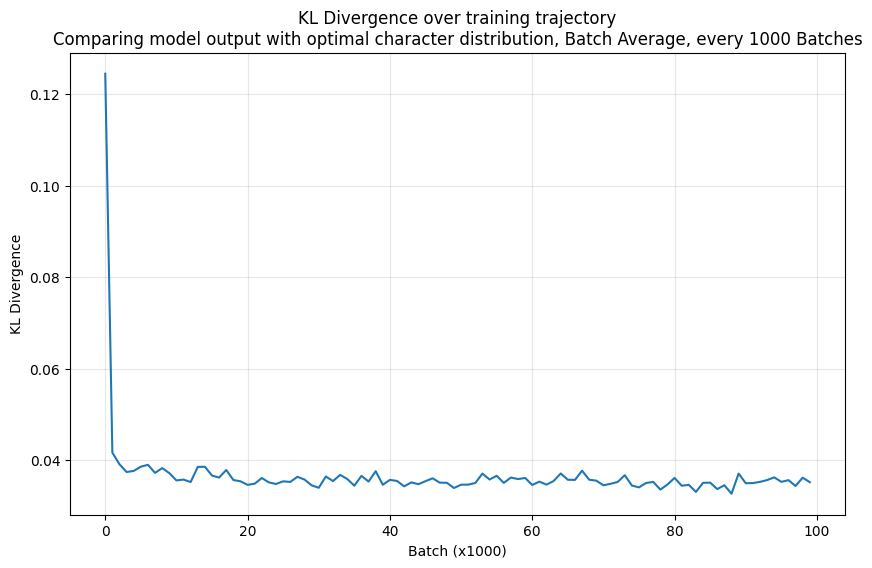

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(kl_trace)
plt.title('KL Divergence over training trajectory\nComparing model output with optimal character distribution, Batch Average, every 1000 Batches')
plt.xlabel('Batch (x1000)')
plt.ylabel('KL Divergence')
plt.grid(True, alpha=0.3)

In [ ]:
sample_ratio = 0.6  # Sample 90% of the data

total_samples = len(dataset)
num_samples = int(total_samples * sample_ratio)
indices = torch.randperm(total_samples)[:num_samples]
sampler = torch.utils.data.SubsetRandomSampler(indices)

# Create a new dataloader with the sampler
small_dataloader = DataLoader(
    dataset,
    batch_size=dataloader.batch_size,
    sampler=sampler,
    num_workers=dataloader.num_workers,
    pin_memory=dataloader.pin_memory,
    drop_last=dataloader.drop_last
)


In [ ]:
mess_1['transition_matrix']

array([[[0.455  , 0.02625, 0.02625],
        [0.0975 , 0.1225 , 0.02625],
        [0.0975 , 0.02625, 0.1225 ]],

       [[0.1225 , 0.0975 , 0.02625],
        [0.02625, 0.455  , 0.02625],
        [0.02625, 0.0975 , 0.1225 ]],

       [[0.1225 , 0.02625, 0.0975 ],
        [0.02625, 0.1225 , 0.0975 ],
        [0.02625, 0.02625, 0.455  ]]])

In [ ]:
from sklearn.linear_model import LinearRegression

best_model = model
best_model.eval()

vocab_size = 3
n_states = 3
N_CTX = 10

mess_1
prior = torch.ones(n_states, dtype=torch.float, device=device) / n_states
T = torch.tensor(mess_1['transition_matrix']).permute(2, 1, 0)

def generate(num_sequences, length):
    tokens = torch.zeros(num_sequences, length, dtype=torch.int64, device=device)
    state = torch.multinomial(prior, num_sequences, replacement=True)
    for i in range(length):
        # probabilities of transitioning to each (state, token) pair
        # indexed as state_idx * vocab_size + token_idx
        pairs_trans = T[state].reshape(num_sequences, -1)
        pairs = torch.multinomial(pairs_trans, 1, replacement=True).squeeze()
        state = pairs // vocab_size
        tokens[:, i] = pairs % vocab_size
    return tokens

def compute_beliefs(tokens):
    num_sequences, length = tokens.shape
    beliefs = torch.zeros(num_sequences, length + 1, n_states, dtype=torch.float64, device=device)
    beliefs[:, 0] = prior
    for i in range(length):
        # unnormalized
        trans_mat = T[..., tokens[:, i]].permute(2, 1, 0)
        beliefs[:, i+1] = (trans_mat @ beliefs[:, i, :, None]).squeeze()
        beliefs[:, i+1] = beliefs[:, i+1] / beliefs[:, i+1].sum(-1, keepdim=True)
    return beliefs

def tokens_to_probe_inputs(tokens):
    with torch.no_grad():
        activation: torch.tensor = None
        def hook(model, input, output):
            nonlocal activation
            activation = output[0]
        hook_handle = best_model.transformer.h[-1].register_forward_hook(hook)
        best_model(tokens)
        hook_handle.remove()
        return activation.reshape(-1, activation.shape[-1])

def tokens_to_probe_targets(tokens):
    beliefs = compute_beliefs(tokens)[:, 1:]
    return beliefs[..., :n_states-1].reshape(-1, n_states-1)

def train_probe(n_samples):
    tokens = generate(n_samples, N_CTX)
    probe_inputs = tokens_to_probe_inputs(tokens).cpu()
    probe_targets = tokens_to_probe_targets(tokens).cpu()
    return LinearRegression().fit(probe_inputs, probe_targets)

In [ ]:
probe = train_probe(n_samples=2000)

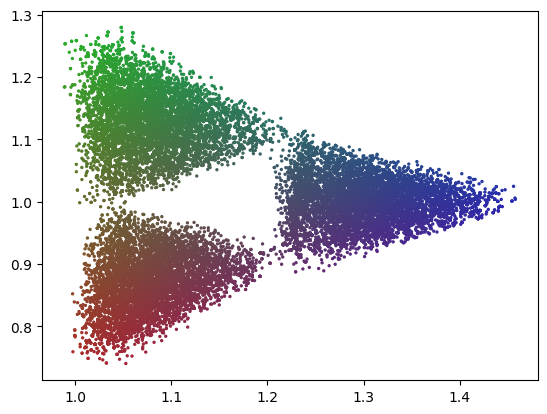

In [ ]:
import PIL.Image

def convert_coords(a, b):
    max_val = 2
    c = max_val - a - b
    y = (2 * b + c) / 2
    x = ((3 ** 0.5) * c) / 2

    a = int(a * 255)
    b = int(b * 255)
    c = 255 - a - b

    colors = [a, b, 255 - a - b]
    return (x,y), colors



sample_size = 5000
outputs_image = torch.zeros((256, 256, 3),  dtype=torch.uint8, device=device)
tokens = generate(sample_size, N_CTX)
probe_inputs = tokens_to_probe_inputs(tokens)
probe_outputs = probe.predict(probe_inputs.cpu())

xs = []
ys = []
cs = []
for probe_res in probe_outputs:
  (x,y),c = convert_coords(a=probe_res[0], b=probe_res[1])
  xs.append(x)
  ys.append(y)
  cs.append(c)

cs = np.array(cs)
cs = cs / 255.0
plt.scatter(xs,ys, c=cs, s=2)

### Using Pure PCA, with no Explicit Probe Training

In [ ]:
target_layer = 3  # last layer in transformer
activations = []
batched_states = []


def hook_fn(module, input, output):
    # Capture the residual stream (input to the layer)
    # print(output[0].shape)
    activations.append(output[0].detach())

# Register the hook to the specified transformer layer
hook = model.transformer.h[target_layer].register_forward_hook(hook_fn)

print(f"Created smaller dataloader with {num_samples} samples (original: {total_samples})")

# Use the smaller dataloader for activation collection
dataloader = small_dataloader


total = 0
with torch.no_grad():
    for i, (data_batch, target, state) in tqdm(enumerate(small_dataloader), desc="Collecting activations"):
        data_batch = data_batch.to(device)
        target = target.to(device)
        total += data_batch.shape[0]
        # Forward pass
        model(data_batch)

        seq_len, batch_size = data_batch.shape

        # if state is not None:  # comment out to save space, overwise OOM
        #     batched_states.append(state.reshape(-1))

# Remove the hook!!! (although it seemingly does not get removed that easily)
hook.remove()

In [ ]:
batched_states = None
data_batch.shape

torch.Size([800, 9])

In [ ]:
print(f"Processing {len(activations)} activation tensors...")
# Concatenate all activations and move to CPU
all_activations = torch.cat([t.cpu().reshape(-1, t.shape[-1]) for t in activations], dim=0)
del activations

# Process states if available
if batched_states:
    labels_state_tensor = torch.cat([st.cpu() for st in batched_states], dim=0)
    labels_state = labels_state_tensor.numpy()
    del labels_state_tensor, batched_states
else:
    labels_state = None

print(f"Collected {all_activations.shape[0]} activation vectors of dimension {all_activations.shape[1]}")

activations_np = all_activations.numpy()
del all_activations


Processing 2250 activation tensors...
Collected 16200000 activation vectors of dimension 64


In [ ]:
import gc
gc.collect()

np.save('/content/drive/MyDrive/stored_activations.np', activations_np)

In [ ]:
ls /content/drive/MyDrive/stored*

/content/drive/MyDrive/stored_activations.np.npy


In [ ]:
activations_np = np.load('/content/drive/MyDrive/stored_activations.np.npy')

In [ ]:
del model
del dataloader


# too many times facing OOM here... much easier to work on Vertex / local
import gc
gc.collect()

70

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3, whiten=False)
activations_2d = pca.fit_transform(activations_np)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.32185847 0.22767732 0.11839504]


In [ ]:
del activations_np

In [ ]:
# get ground truth believe states for each trajectory
all_belief_histories = []
for i, (data_batch, target, state) in tqdm(enumerate(small_dataloader), desc="Collecting activations"):
  for seq in data_batch:
    belief_history_trace = get_belief_history(mess_1, seq.cpu().detach().numpy())
    all_belief_histories.append(np.array(belief_history_trace)[:9]) # activations are of size 9, absent for last position

all_belief_histories = np.stack(all_belief_histories)

In [ ]:
all_belief_histories = all_belief_histories.reshape(-1, 3)

In [ ]:
# Normalize PCA components to sum to 1 (for simplex projection)
row_sums = np.abs(activations_2d).sum(axis=1)
normalized_activations = np.abs(activations_2d) / row_sums[:, np.newaxis]

# Project onto 2D simplex
beliefs_to_simplex = np.array(activations_2d) @ SIMPLEX_PROJ

Results Below look dissimilar from the ground truth - 1. My first hypothesis was that it mostly due to 40% of the samples missing
2. However we are missing not 40% of *activations* but 40% of *samples* - hence the idea that those disproportionately contribute to narrow linkes between larger triangular clusters seems less likely
3. still it is intuitive that the narrow links shaping the marginal transitions between State-specific areas of Belief Space would suffer degratation from noize first
4. Overall the "Fractal Structure" is replicated, albeit not precisely

In [ ]:
# colors = [tuple(b) for b in all_belief_histories]

plt.figure(figsize=(10, 10)) # colors below are commented out because after another OOM I had to recompute them
plt.scatter(beliefs_to_simplex[:, 0], beliefs_to_simplex[:, 1], c=None, # colors
            alpha=0.8, s=0.01)
# plt.plot(SIMPLEX_BOUNDARY_X, SIMPLEX_BOUNDARY_Y,)  # Draw the simplex boundary

plt.colorbar(label='State Value')

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import softmax # Renormalize PCA outputs to SoftMaxed Probs


# Centers data (mean=0) and scales to unit variance
scaler = StandardScaler()

preprocessed_activations = scaler.fit_transform(activations_np)
# whiten=False is standard unless you specifically need it
pca = PCA(n_components=3, whiten=False)
activations_pca_3d = pca.fit_transform(preprocessed_activations)
print(f"PCA complete. Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Sum of explained variance: {pca.explained_variance_ratio_.sum()}")


# apply softmax row-wise to the 3 PCA components ????
# Softmax should push data to the edges of the Simplex
# Potentially making topological strucutres (holes) more visible
# But it also defeats the idea that Transformer encoder Belief State Geometry Linearly
# So should be seen only as a magnifying tool
activations_probs = softmax(activations_pca_3d, axis=1)


projected_points = activations_probs @ SIMPLEX_PROJ
print(f"Projection complete. Shape: {projected_points.shape}")


print("Plotting...")
plt.figure(figsize=(10, 8))


vertices = np.array([[1,0,0], [0,1,0], [0,0,1]]) @ SIMPLEX_PROJ
triangle = plt.Polygon(vertices, fill=None, edgecolor='k', linewidth=1.5, linestyle='--')
plt.gca().add_patch(triangle)


if 'colors' not in locals() or len(colors) != projected_points.shape[0]:
     print("Warning: 'colors' variable not defined or length mismatch. Using default color.")
     colors = 'blue'

plt.scatter(projected_points[:, 0], projected_points[:, 1], c=colors, alpha=0.5, s=0.1)
# plt.colorbar(label='State Value')

plt.title('PCA Activations (Top 3 Components -> Softmax -> Simplex Projection)')
plt.xlabel('Simplex Dimension 1')
plt.ylabel('Simplex Dimension 2')
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()
